# 03 — FX Impact & Won-Denominated Cost Decomposition

Feeds report **Section 4 (FX Impact)**.

Question: how much of the Korean importer's *won-denominated* cost surge came from the
world coffee price (USD) vs. from the won weakening (USD/KRW)?

Inputs:
- `data/processed/price_vs_import_unitprice.csv` — Korea import unit price (USD/kg) + world prices (from notebook 02)
- `data/raw/fx_usdkrw_ecb_2024_2026.csv` — USD/KRW monthly avg (ECB reference rate via Frankfurter; `scripts/fetch_fx.py`)

Method: `cost_KRW = price_USD × FX`. In logs this is exactly additive, so the change in
won cost splits cleanly into a **price effect** and an **FX effect**.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

px = pd.read_csv("../data/processed/price_vs_import_unitprice.csv")
fx = pd.read_csv("../data/raw/fx_usdkrw_ecb_2024_2026.csv")[["year_month", "usdkrw_avg", "n_obs"]]

df = px.merge(fx, on="year_month", how="left")            # inner range = 2024-01..2026-03
df["date"] = pd.to_datetime(df["year_month"], format="%Y-%m")
df["import_krw_per_kg"]  = df["korea_import_usd_per_kg"] * df["usdkrw_avg"]
df["arabica_krw_per_kg"] = df["arabica_otm_usd_per_kg"]  * df["usdkrw_avg"]
assert df["usdkrw_avg"].notna().all(), "missing FX month"
print(df["year_month"].min(), "->", df["year_month"].max(), "|", len(df), "months")
df[["year_month","korea_import_usd_per_kg","usdkrw_avg","import_krw_per_kg"]].head()

2024-01 -> 2026-03 | 27 months


,year_month,korea_import_usd_per_kg,usdkrw_avg,import_krw_per_kg
0,2024-01,3.881,1327.10,5150.47510
1,2024-02,3.942,1331.56,5249.00952
2,2024-03,4.147,1331.98,5523.72106
3,2024-04,4.246,1369.83,5816.29818
4,2024-05,4.522,1364.17,6168.77674


### Decomposition: price effect vs FX effect

In [2]:
base, last = df.iloc[0], df.iloc[-1]

def decomp(a_usd, a_fx, b_usd, b_fx):
    a_krw, b_krw = a_usd*a_fx, b_usd*b_fx
    dln_krw = np.log(b_krw/a_krw)
    dln_usd = np.log(b_usd/a_usd)
    dln_fx  = np.log(b_fx/a_fx)
    return {
        "krw_change_pct": b_krw/a_krw - 1,
        "usd_change_pct": b_usd/a_usd - 1,
        "fx_change_pct":  b_fx/a_fx - 1,
        "price_contrib":  dln_usd/dln_krw,
        "fx_contrib":     dln_fx/dln_krw,
    }

# (a) single-month endpoints
ep = decomp(base.korea_import_usd_per_kg, base.usdkrw_avg, last.korea_import_usd_per_kg, last.usdkrw_avg)
# (b) 3-month-average basis (robust, matches Section 2 style)
f3, l3 = df.head(3), df.tail(3)
avg = decomp(f3.korea_import_usd_per_kg.mean(), f3.usdkrw_avg.mean(),
             l3.korea_import_usd_per_kg.mean(), l3.usdkrw_avg.mean())

print(f"BASE {base.year_month}: {base.korea_import_usd_per_kg:.3f} USD/kg x {base.usdkrw_avg:.0f} = {base.import_krw_per_kg:,.0f} KRW/kg")
print(f"LAST {last.year_month}: {last.korea_import_usd_per_kg:.3f} USD/kg x {last.usdkrw_avg:.0f} = {last.import_krw_per_kg:,.0f} KRW/kg")
for name, d in [("single-month endpoints", ep), ("3-month-avg basis", avg)]:
    print(f"\n[{name}]")
    print(f"  KRW cost {d['krw_change_pct']:+.1%}  =  price {d['usd_change_pct']:+.1%}  &  FX {d['fx_change_pct']:+.1%}")
    print(f"  contribution -> price {d['price_contrib']:.0%} | FX {d['fx_contrib']:.0%}")

BASE 2024-01: 3.881 USD/kg x 1327 = 5,150 KRW/kg
LAST 2026-03: 7.398 USD/kg x 1491 = 11,030 KRW/kg

[single-month endpoints]
  KRW cost +114.1%  =  price +90.6%  &  FX +12.3%
  contribution -> price 85% | FX 15%

[3-month-avg basis]
  KRW cost +98.6%  =  price +80.3%  &  FX +10.2%
  contribution -> price 86% | FX 14%


### The FX 'offset' — why won-buyers felt no price relief

USD prices peaked **2025-05** and then eased; check what FX did to the won cost over the same window.

In [3]:
pk = df.loc[df["korea_import_usd_per_kg"].idxmax()]      # USD price peak month
end = df.iloc[-1]
print(f"USD price peak  {pk.year_month}: {pk.korea_import_usd_per_kg:.3f} USD/kg | FX {pk.usdkrw_avg:.0f} | {pk.import_krw_per_kg:,.0f} KRW/kg")
print(f"latest          {end.year_month}: {end.korea_import_usd_per_kg:.3f} USD/kg | FX {end.usdkrw_avg:.0f} | {end.import_krw_per_kg:,.0f} KRW/kg")
print(f"\n  USD price {end.korea_import_usd_per_kg/pk.korea_import_usd_per_kg-1:+.1%}  but  FX {end.usdkrw_avg/pk.usdkrw_avg-1:+.1%}")
print(f"  => won cost {end.import_krw_per_kg/pk.import_krw_per_kg-1:+.1%}  (price relief offset by weaker won)")

out = df[["year_month","korea_import_usd_per_kg","arabica_otm_usd_per_kg","usdkrw_avg",
          "import_krw_per_kg","arabica_krw_per_kg"]].copy()
out.to_csv("../data/processed/fx_and_cost_decomposition.csv", index=False, encoding="utf-8-sig")
print("\nsaved -> data/processed/fx_and_cost_decomposition.csv", out.shape)

USD price peak  2025-05: 7.976 USD/kg | FX 1389 | 11,077 KRW/kg
latest          2026-03: 7.398 USD/kg | FX 1491 | 11,030 KRW/kg

  USD price -7.2%  but  FX +7.4%
  => won cost -0.4%  (price relief offset by weaker won)

saved -> data/processed/fx_and_cost_decomposition.csv (27, 6)


### Figure 4-1 — USD/KRW monthly average

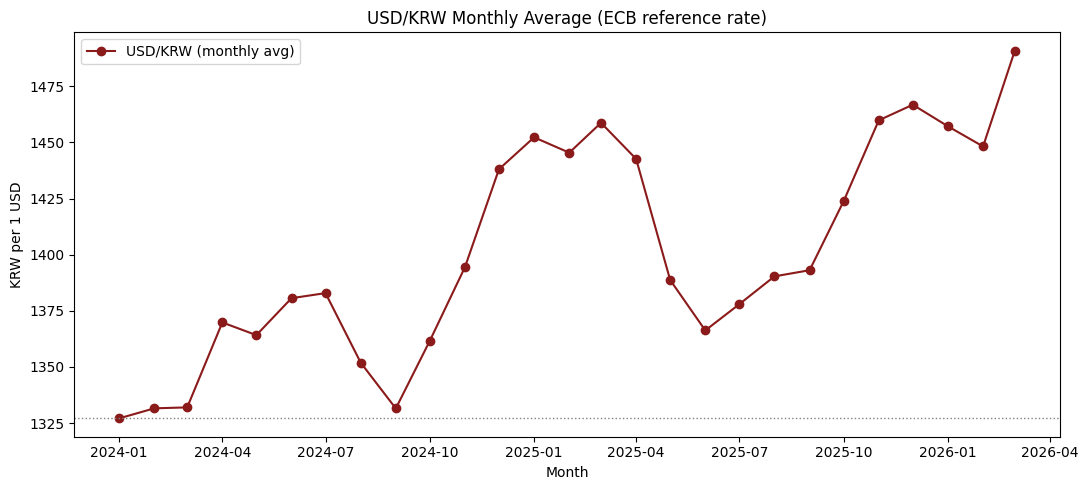

In [4]:
plt.figure(figsize=(11, 5))
plt.plot(df["date"], df["usdkrw_avg"], marker="o", color="#8b1a1a", label="USD/KRW (monthly avg)")
plt.axhline(df["usdkrw_avg"].iloc[0], color="grey", ls=":", lw=1)
plt.ylabel("KRW per 1 USD")
plt.xlabel("Month")
plt.title("USD/KRW Monthly Average (ECB reference rate)")
plt.legend()
plt.tight_layout()
plt.savefig("../reports/figures/05_fx_usdkrw_trend.png", dpi=130, bbox_inches="tight")
plt.show()

### Figure 4-2 — Won cost = world price x FX (indexed, 2024-01 = 100)

The navy line (won cost) is the brown line (USD price) **lifted by** the teal line (FX).
The vertical gap between brown and navy is the FX contribution.

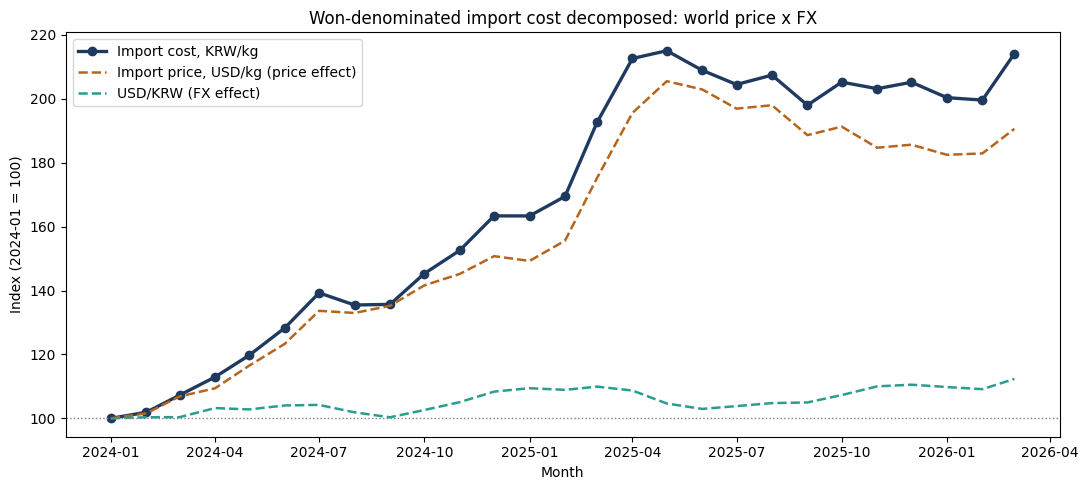

In [5]:
idx = df.set_index("date")[["korea_import_usd_per_kg","usdkrw_avg","import_krw_per_kg"]]
idx = idx / idx.iloc[0] * 100
plt.figure(figsize=(11, 5))
plt.plot(idx.index, idx["import_krw_per_kg"], color="#1f3a5f", lw=2.4, marker="o", label="Import cost, KRW/kg")
plt.plot(idx.index, idx["korea_import_usd_per_kg"], color="#b5651d", ls="--", lw=1.8, label="Import price, USD/kg (price effect)")
plt.plot(idx.index, idx["usdkrw_avg"], color="#2a9d8f", ls="--", lw=1.8, label="USD/KRW (FX effect)")
plt.axhline(100, color="grey", ls=":", lw=1)
plt.ylabel("Index (2024-01 = 100)")
plt.xlabel("Month")
plt.title("Won-denominated import cost decomposed: world price x FX")
plt.legend()
plt.tight_layout()
plt.savefig("../reports/figures/06_krw_cost_decomposition.png", dpi=130, bbox_inches="tight")
plt.show()

**Key findings (-> Section 4)**
- Won import cost roughly **doubled** (5,150 -> 11,030 KRW/kg); ~85% world price, ~15% FX.
- "이중 비용 압박" is real but **asymmetric** — FX is a secondary amplifier, not co-equal.
- FX is **non-monotonic**: won strengthened mid-2025 (cushion), then weakened again.
- From the 2025-05 USD-price peak, world price eased ~7% but the won weakened ~7%, so
  **won cost stayed flat** — importers felt no relief.